# Missing Values- Feature Engineering- Day 1
Lifecycle of a Data Science Projects

Data Collection Statergy---from company side,3rd party APi's,Surveys,Surveys
Feature Engineering---Handling Missing Values
Why are their Missing values?? Survey--Depression Survey

They hesitate to put down the information
Survey informations are not that valid
Men--salary
Women---age
People may have died----NAN
Data Science Projects---Dataset should be collected from multiple sources

# What are the different types of Missing Data?
# Missing Completely at Random, MCAR:
A variable is missing completely at random (MCAR) if the probability of being missing is the same for all the observations. When data is MCAR, there is absolutely no relationship between the data missing and any other values, observed or missing, within the dataset. In other words, those missing data points are a random subset of the data. There is nothing systematic going on that makes some data more likely to be missing than other.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score


In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#NOTE - Age and Cabin data are corelated though in the problem statement they have said they dont. Cause the data is after the accident happened so here we can see that for age there was no body left from many families to tell the ages. smae goes for cabin which pean people staying with no ages could be the one responsible for the NAN values in Cabin.

In [6]:
df[df[['Age','Cabin']].isnull().all(axis=1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


#NOTE - here we can see that Embarked is the feature whcih dosent match to anything or we can say not related

In [7]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


#SECTION - 2.Missing data at random(MNAR): Systematic missing Value

there is absolutely some relationship between  the data missing and any other values, observed or missing, within the dataset.

In [8]:
df['Cabin_null']=np.where(df['Cabin'].isnull(),1,0)
#find the percentage of null values

df['Cabin_null'].mean()

np.float64(0.7710437710437711)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_null
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [10]:
#let us see the value of wether survived = cabin should not be missing 
df.groupby(['Survived'])['Cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: Cabin_null, dtype: float64

# Missing at random values(MAR
)

men hide thier salary

women hide their age

all the techniques to handel missing values
1. Mean/ MEdian Mode replacement
2. random sample imputation
3. Capturing nan values with  a new feature 
4. end of distribution imputation
5. arbitrary imputation
6. frequent categories imputation
7. 

#### Mean/Median/Mode
When should we apply?

mead/median imputation has the  assumption that the data  are missing completely at random(MCAR).

solve this by replacing the NaN with the most frequent occurance of the variable.

In [11]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [12]:
## let us go  and see the percentage  of missing values
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [13]:
#here as we can seee that age is haing 0.19 percent of data missing thats why we ahve done imputation for AGE

In [14]:
#median is used as it posses the mostfrequnt count of number and as the datset vcould have outlier so meadian is best for that where MEAN fails.
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)

In [15]:
median=df.Age.median()
median

np.float64(28.0)

In [16]:
impute_nan(df,'Age',median)
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [17]:
#now check for the std of "Age", "Age_median"

In [18]:
print(df['Age'].std())
print(df['Age_median'].std())

14.526497332334042
13.019696550973201


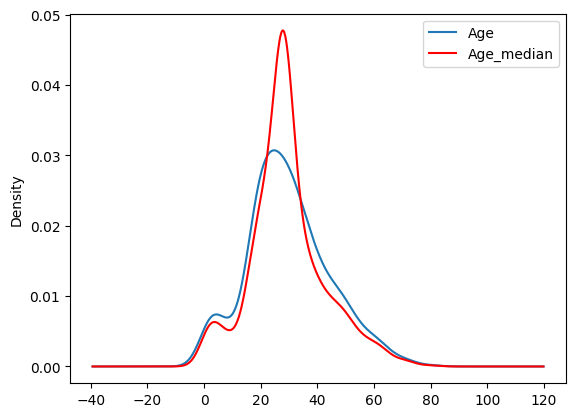

In [19]:
fig = plt.figure()
ax=fig.add_subplot(111)
df['Age'].plot(kind='kde',ax=ax)#kde = kernel desity estimators
df.Age_median.plot(kind='kde',ax=ax,color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

### advantages of mean/median  impotation

#### advantages
1. Easy to implemetn(robbust to outlier)
2. faster way t cmplete the dataset

#### disadvantages
1. change or distortion  in the original variance
2. impacts the corelations

# Random sammple imputation 
rsi consist of taking random observation from the dataset and we use  this observation to replace the nan values


when it should be use ?

assumption that the data  are missing completely at random(MCAR).


In [41]:
df=pd.read_csv("titanic.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [42]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [43]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [44]:
df['Age'].isnull().sum()

np.int64(177)

In [24]:
df['Age'].dropna().sample(df['Age'].isnull().sum(),random_state=0)

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [45]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [46]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)
    df[variable+"_random"]=df[variable]
    #it will have the random sample to fill the nan value 
    random_sample = df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
    #pandas nedds to have the same index in order to merge the dataset
    random_sample.index=df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable+'_random']=random_sample


In [48]:
median = df.Age.median()

In [49]:
median

np.float64(28.0)

In [50]:
impute_nan(df,"Age",median)

In [51]:
df.head()

,Survived,Age,Fare,Age_median,Age_random
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


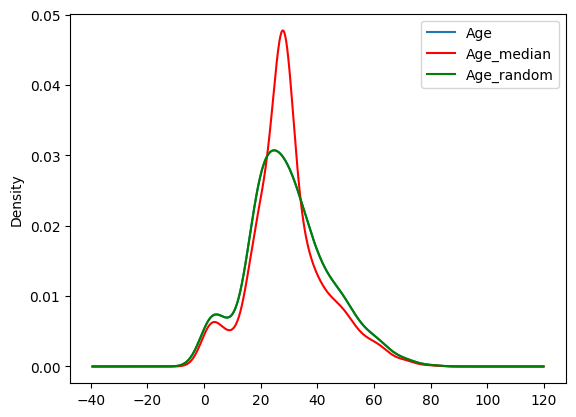

In [54]:
fig = plt.figure()
ax=fig.add_subplot(111)
df['Age'].plot(kind='kde',ax=ax)#kde = kernel desity estimators
df.Age_median.plot(kind='kde',ax=ax,color='red')
df.Age_random.plot(kind='kde',ax=ax,color='green')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [29]:
X=df.drop(['Survived'],axis=1)
y=df['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

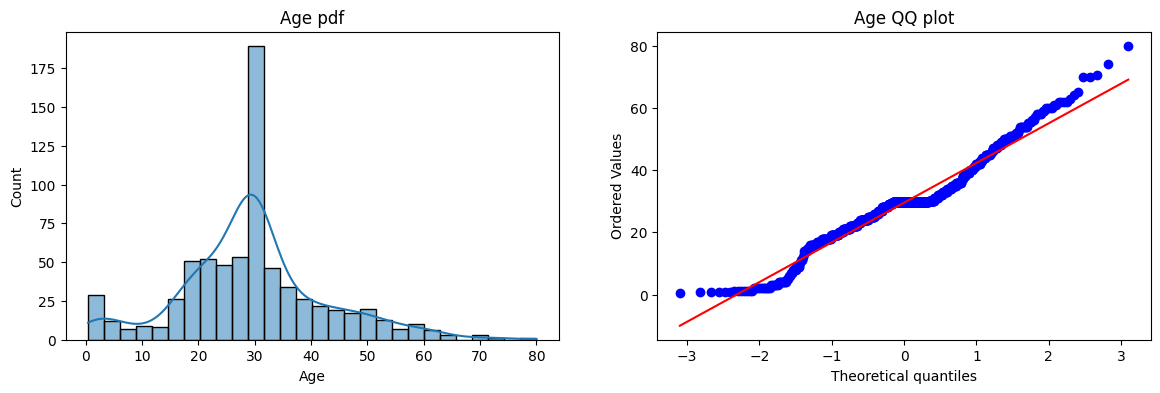

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age pdf')

plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist="norm",plot=plt)
plt.title('Age QQ plot')

plt.show()

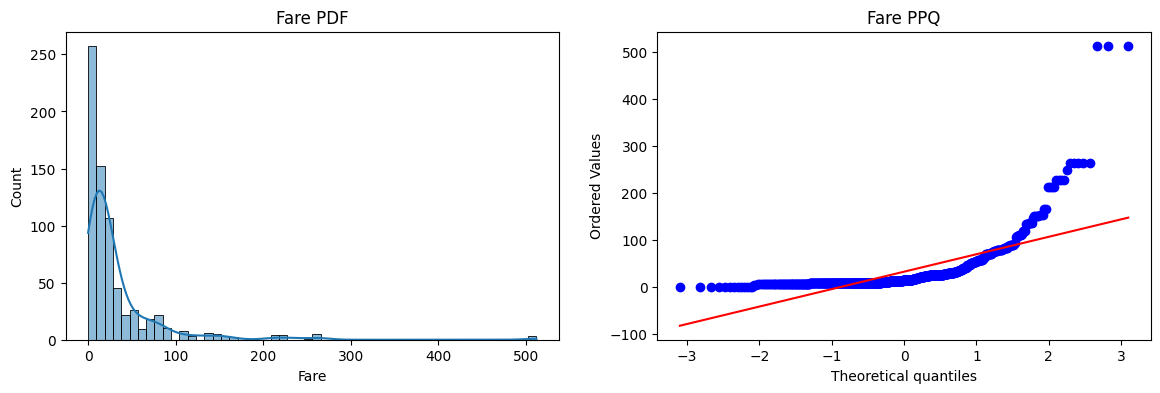

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(X_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist="norm",plot=plt)
plt.title("Fare PPQ")
plt.show()  # so here we can see that there is right skew graph whihc is beign made 

In [32]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [33]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))


Accuracy LR 0.6480446927374302
Accuracy DT 0.6927374301675978


In [34]:
## applying the log transformer function over the dataset 

trf = FunctionTransformer(func= np.log1p)

In [35]:
X_train_transformed = trf.fit_transform(X_train)
X_test_tranformed = trf.fit_transform(X_test)

In [36]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_tranformed)
y_pred1= clf2.predict(X_test_tranformed)

print("Accuracy",accuracy_score(y_test,y_pred))
print("Accuracy",accuracy_score(y_test,y_pred1))
#here we are getting changes in LR not in DTC so here we can say for lr we have to cross validation

Accuracy 0.6815642458100558
Accuracy 0.6815642458100558


In [37]:
#cross validation again to check the LR and DTC
"""basically it Splits your dataset into k chunks(called folds, e.g., k=5 → 5 folds).
Trains on (k-1) folds and tests on the remaining 1 fold.
Repeats this process k times (so every fold gets to be the test set once).
Averages the results → more reliable estimate of model performance."""


X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Lr",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

#now here we can see that after calculating the mean we can see the lr stays 67 which means there is some improvement

Lr 0.678027465667915
DT 0.6521348314606741


Text(0.5, 1.0, 'fare after log')

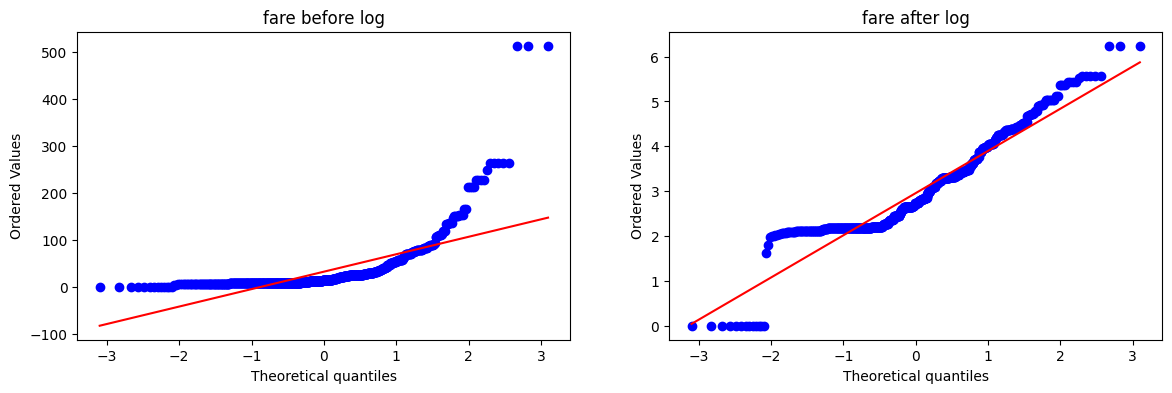

In [38]:
#comparison between original fare AND fare after log
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('fare before log')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('fare after log')

Text(0.5, 1.0, 'Age after log')

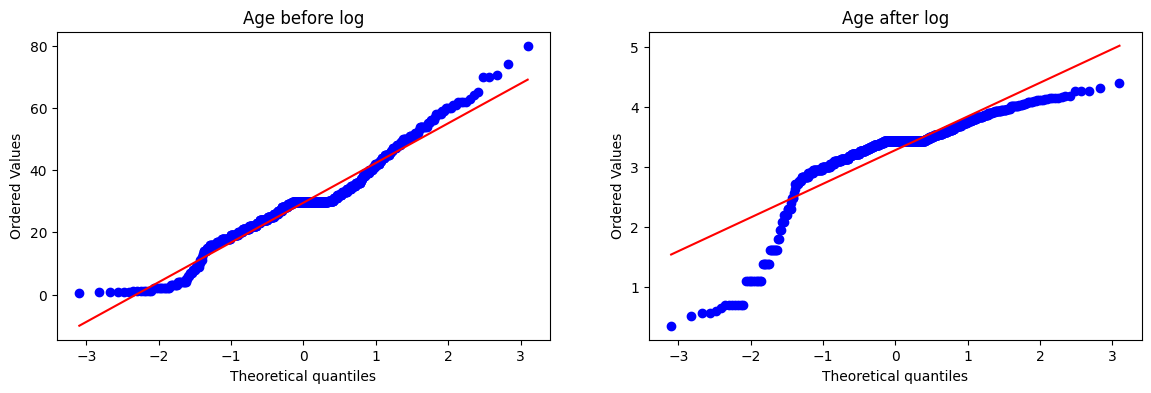

In [39]:
#comparison between original Age AND Age after log
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age before log')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age after log')